## Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_util import *

In [3]:
import time

In [5]:
no_epochs=20
val_split=0.15
sequence_length = 16  # sequence length

#### Tranining Data set

In [8]:
train_df = read_data(get_files(r'.*Case[1-6]_CutFre20.xls'),cut_precent=0.1) # case 1 -6 for traning
train_df.head()

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


,distance,acceleration,displacement,force
0,195.166667,-0.971085,0.058862,171.311496
1,195.250000,-1.077395,0.058892,171.652377
2,195.333333,-1.167291,0.058921,171.871397
3,195.416667,-1.239130,0.058949,171.960719
4,195.500000,-1.291503,0.058976,171.913955


In [10]:
# Selecting the relevant features
train_features = train_df[['acceleration', 'displacement']]
train_target = train_df['force']

X_train, y_train, distance = create_sequences(train_features, train_target, train_df['distance'],sequence_length)

#### Testing Data set

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Conv1D, Dense,LSTM,Bidirectional,Input,GRU,Flatten,Dropout,Attention
from tensorflow.keras import regularizers
from tensorflow import keras

In [14]:
SMALL_SIZE = 16
MEDIUM_SIZE = 16
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["figure.figsize"] = (8,6)
plt.style.use("classic")


In [17]:
lstm_model = keras.models.load_model("models/Fre20_20/lstm_model_fre_20_20.keras")
rnn_model = keras.models.load_model("models/Fre20_20/rnn_model_fre_20_20.keras")
gru_model = keras.models.load_model("models/Fre20_20/rnn_model_fre_20_20.keras")
cnn_gru_model = keras.models.load_model("models/Fre20_20/cnn_gru_model_fre_20_20.keras")

In [19]:
test_df = read_data(get_files(r'V300.*Case7_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test300, y_test300,idx300 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


In [21]:
rnn_pred = rnn_model.predict(X_test300)
gru_pred = gru_model.predict(X_test300)
lstm_pred = lstm_model.predict(X_test300)
cnn_gru_pred = cnn_gru_model.predict(X_test300)

391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 425us/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step


In [22]:
test_df = read_data(get_files(r'V380.*Case8_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
X_test380, y_test380,idx380 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


In [25]:
rnn_pred1 = rnn_model.predict(X_test380)
gru_pred1 = gru_model.predict(X_test380)
lstm_pred1 = lstm_model.predict(X_test380)
cnn_gru_pred1 = cnn_gru_model.predict(X_test380)

343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [27]:

from matplotlib.backends.backend_pdf import PdfPages

def plot_combined(filename="combined_image",start1=1200, end1=1401,start2=150, end2=200):
    # Create a figure with two subplots (1 row, 2 columns)
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=False)  # No shared x-axis

    # First plot

    epoch_count1 = idx300[start1:end1]
    axs[0].plot(epoch_count1, y_test300[start1:end1], 'ro-', linewidth=2.0, markevery=20)
    axs[0].plot(epoch_count1, gru_pred[start1:end1], 'm^--', linewidth=2.0, markevery=20)
    axs[0].plot(epoch_count1, cnn_gru_pred[start1:end1], 'bX--', linewidth=2.0, markevery=20)
    axs[0].plot(epoch_count1, rnn_pred[start1:end1], 'yh--', linewidth=2.0, markevery=20)
    axs[0].plot(epoch_count1, lstm_pred[start1:end1], 'gd--', linewidth=2.0, markevery=20)
    axs[0].grid(True)
    axs[0].text(-0.1, 1.05, '(a)', transform=axs[0].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

    # Second plot
    epoch_count2 = idx380[start2:end2]
    axs[1].plot(epoch_count2, y_test380[start2:end2], 'ro-', linewidth=2.0, markevery=20)
    axs[1].plot(epoch_count2, gru_pred1[start2:end2], 'm^--', linewidth=2.0, markevery=20)
    axs[1].plot(epoch_count2, cnn_gru_pred1[start2:end2], 'bX--', linewidth=2.0, markevery=20)
    axs[1].plot(epoch_count2, rnn_pred1[start2:end2], 'yh--', linewidth=2.0, markevery=20)
    axs[1].plot(epoch_count2, lstm_pred1[start2:end2], 'gd--', linewidth=2.0, markevery=20)
    axs[1].grid(True)
    axs[1].text(-0.1, 1.05, '(b)', transform=axs[1].transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

    # Add shared x-label for the entire figure
    fig.text(0.5, 0.005, 'Distance (m)', ha='center', fontsize=16)
    # Add shared y-label for the entire figure
    fig.text(0.02, 0.5, 'Force (N)', va='center', rotation='vertical', fontsize=16)

    # Add a single legend
    labels = ['Force', "GRU", "CNN-GRU", "RNN", "LSTM"]
    fig.legend(labels, loc='upper center', ncol=5, fontsize=14, bbox_to_anchor=(0.5, 1.0))

    # Rotate x-axis tick labels
    for ax in axs:
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    # Adjust spacing
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # Save to PDF
    with PdfPages("images/" + filename + ".pdf") as pdf:
        pdf.savefig(fig, dpi=200)

    # Optionally, display the combined plot
    plt.show()

# Call the function to generate and save the combined image
# plot_combined("combined_case7_8")


In [29]:
test_df = read_data(get_files(r'V350.*Case7_CutFre50.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test300, y_test300,idx300 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

rnn_pred = rnn_model.predict(X_test300)
gru_pred = gru_model.predict(X_test300)
lstm_pred = lstm_model.predict(X_test300)
cnn_gru_pred = cnn_gru_model.predict(X_test300)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 710us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step


In [31]:
test_df = read_data(get_files(r'V380.*Case8_CutFre200.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
X_test380, y_test380,idx380 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


In [33]:
rnn_pred1 = rnn_model.predict(X_test380)
gru_pred1 = gru_model.predict(X_test380)
lstm_pred1 = lstm_model.predict(X_test380)
cnn_gru_pred1 = cnn_gru_model.predict(X_test380)

343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step


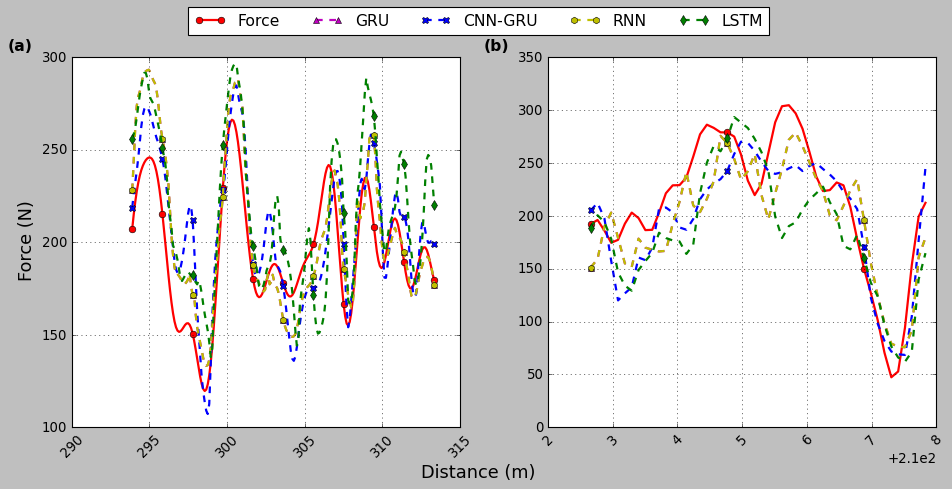

In [35]:
plot_combined("Strategy4")

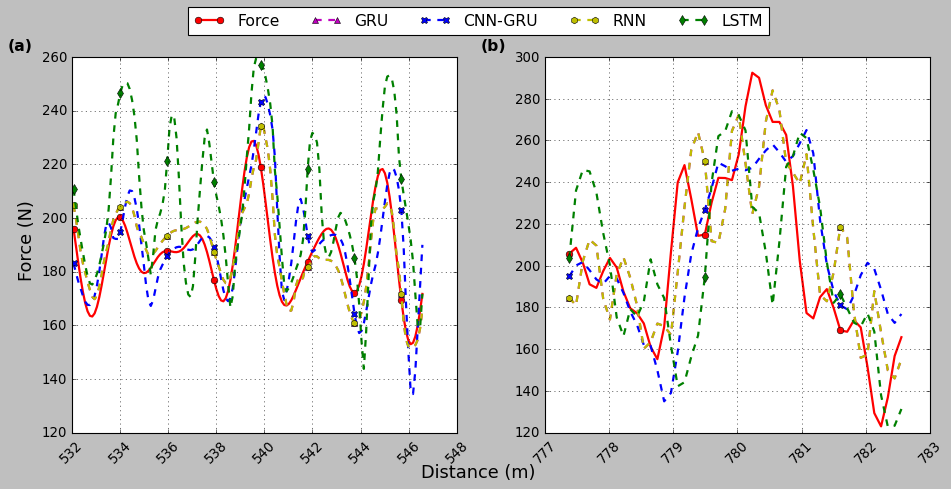

In [63]:
plot_combined("Strategy41",start1=3650, end1=3800,start2=5500, end2=5550)

In [174]:
rnn_model = keras.models.load_model("models/rnn_model_fre_20_20.keras")
gru_model = keras.models.load_model("models/rnn_model_fre_20_20.keras")
cnn_gru_model = keras.models.load_model("models/cnn_gru_model_fre_20_20.keras")

In [246]:
test_df = read_data(get_files(r'V350.*Case7_CutFre50.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test300, y_test300,idx300 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

rnn_pred = rnn_model.predict(X_test300)
gru_pred = gru_model.predict(X_test300)
lstm_pred = lstm_model.predict(X_test300)
cnn_gru_pred = cnn_gru_model.predict(X_test300)

118/336 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 424us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step


In [248]:
test_df = read_data(get_files(r'V380.*Case8_CutFre150.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
X_test380, y_test380,idx380 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)
rnn_pred1 = rnn_model.predict(X_test380)
gru_pred1 = gru_model.predict(X_test380)
lstm_pred1 = lstm_model.predict(X_test380)
cnn_gru_pred1 = cnn_gru_model.predict(X_test380)

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step


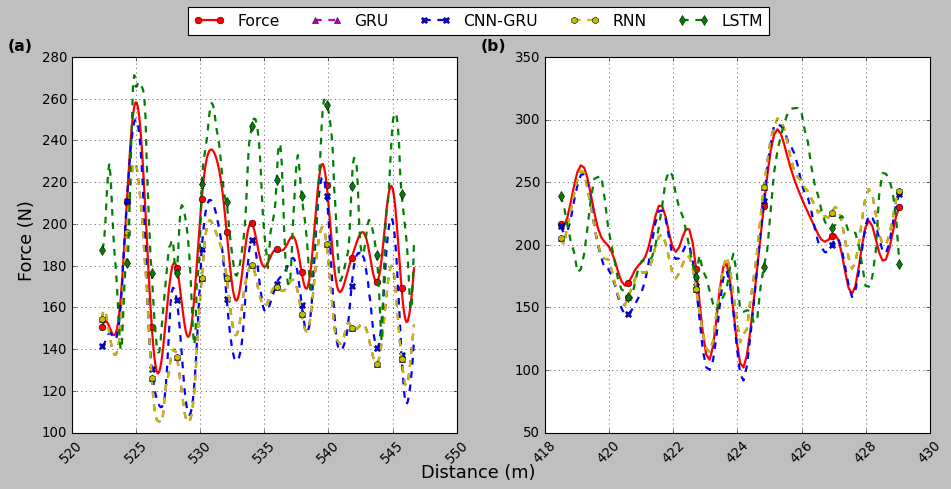

In [258]:
plot_combined(filename="stratage2",start1=3550, end1=3801,start2=2100, end2=2201)

In [260]:
test_df = read_data(get_files(r'V350.*Case7_CutFre200.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]

X_test300, y_test300,idx300 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)

rnn_pred = rnn_model.predict(X_test300)
gru_pred = gru_model.predict(X_test300)
lstm_pred = lstm_model.predict(X_test300)
cnn_gru_pred = cnn_gru_model.predict(X_test300)

test_df = read_data(get_files(r'V380.*Case8_CutFre200.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
X_test380, y_test380,idx380 = create_sequences(test_features, test_df['force'],test_df['distance'],sequence_length)
rnn_pred1 = rnn_model.predict(X_test380)
gru_pred1 = gru_model.predict(X_test380)
lstm_pred1 = lstm_model.predict(X_test380)
cnn_gru_pred1 = cnn_gru_model.predict(X_test380)

118/336 ━━━━━━━━━━━━━━━━━━━━ 0s 430us/step

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 429us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step
336/336 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step
122/343 ━━━━━━━━━━━━━━━━━━━━ 0s 414us/step

/Users/lahaale/Downloads/RL_network/BRNN_mobile_egde/data_Railway/data_util.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df,df_tmp] )


343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 416us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 412us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 720us/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 798us/step


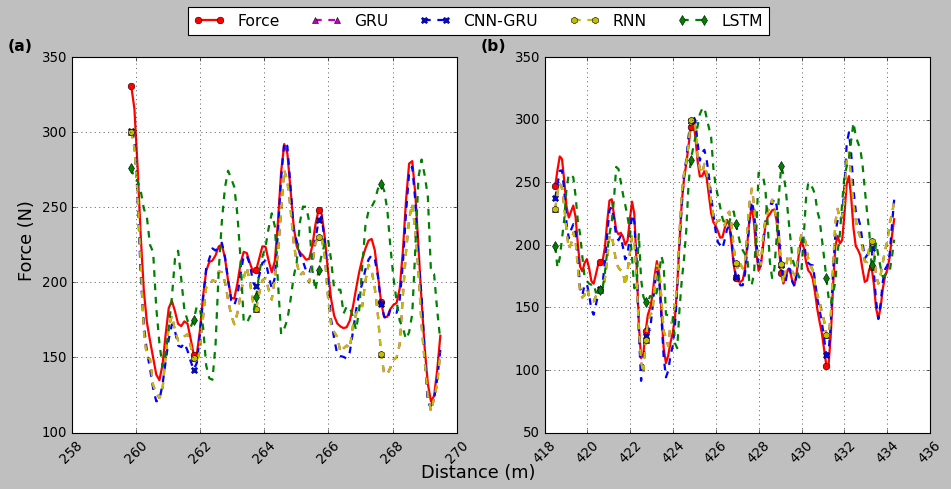

In [286]:
plot_combined(filename="stratage3",start1=850, end1=950,start2=2100, end2=2251)